In [81]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

sys.path.insert(0, "src")

from pandas import DataFrame
from analytics.metrics.metric import MetricCalculator
from analytics.metrics.time import TimeMetrics
from spec.enums import MainTableColumns as Cols
from spec.spec_definition import PS2Versions
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [82]:
from analytics.preprocessors.edwards import TimeStampToDateTimePreprocessor
from analytics.preprocessors.codebench import YAMLLinkURLPreprocessor
from analytics.ps2_dataset import SortPreprocessor

config_path = None
problem_id_col = None
timestamp_col = None
idle_gap = None
break_gap = None
proprocessing_steps = []
link_preprocessing_steps = []

edwards2021_config = {
    "config_path": "sample_data_configs/edwards2021.yaml",
    "problem_id_col": Cols.AssignmentID,
    "timestamp_col": Cols.ClientTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "proprocessing_steps": [
        TimeStampToDateTimePreprocessor(),
        SortPreprocessor()
    ],
}

cwo_s19_config = {
    "config_path": "sample_data_configs/cwo_s19.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 5 * 60,
    "break_gap": 30 * 60,
    "proprocessing_steps": [
        SortPreprocessor()
    ],
}

codebench2024_config = {
    "config_path": "sample_data_configs/codebench2024.yaml",
    "problem_id_col": Cols.ProblemID,
    "timestamp_col": Cols.ServerTimestamp,
    "idle_gap": 30,
    "break_gap": 3 * 60,
    "link_preprocessing_steps": [YAMLLinkURLPreprocessor(True)],

}

# config = codebench2024_config
config = cwo_s19_config
locals().update(config)

In [83]:
from database.config import PS2DataConfig

spec = PS2Versions.v1_0.load()

data_config = PS2DataConfig.from_yaml(config_path, spec)


In [84]:
from analytics.ps2_dataset import PS2Dataset

dataset = PS2Dataset(spec, data_config)
for i, step in enumerate(proprocessing_steps):
    dataset.main_table_preprocessors.insert(i, step)
for i, step in enumerate(link_preprocessing_steps):
    dataset.link_table_preprocessors.insert(i, step)

In [85]:
main_table = dataset.get_main_table()
main_table.head()

,Order,SubjectID,ToolInstances,ServerTimestamp,ServerTimezone,CourseID,CourseSectionID,AssignmentID,ProblemID,Attempt,CodeStateID,IsEventOrderingConsistent,EventType,Score,Compile.Result,CompileMessageType,CompileMessageData,EventID,ParentEventID,SourceLocation
0,0,f40a635828e2bffd0a598a7ed621fc93,Java 8; CodeWorkout,2019-03-20 19:34:25,0,CS 1,1,492.0,32,25,548938774dc948448b0bb51139bbcae3a3966ab8,True,Run.Program,1.0,NaN,NaN,NaN,32-84779,NaN,NaN
1,1,f40a635828e2bffd0a598a7ed621fc93,Java 8; CodeWorkout,2019-03-20 19:34:25,0,CS 1,1,492.0,32,25,548938774dc948448b0bb51139bbcae3a3966ab8,True,Compile,NaN,Success,NaN,NaN,32-84780,32-84779,NaN
2,2,f18374bf891c9af64c8570448824202d,Java 8; CodeWorkout,2019-03-20 21:02:00,0,CS 1,2,492.0,32,1,20dc599067ac07408b5636973fc6b8a37db9af32,True,Run.Program,1.0,NaN,NaN,NaN,32-84781,NaN,NaN
3,3,f18374bf891c9af64c8570448824202d,Java 8; CodeWorkout,2019-03-20 21:02:00,0,CS 1,2,492.0,32,1,20dc599067ac07408b5636973fc6b8a37db9af32,True,Compile,NaN,Success,NaN,NaN,32-84782,32-84781,NaN
4,4,4d230b683bf9840553ae57f4acc96e81,Java 8; CodeWorkout,2019-03-20 21:13:09,0,CS 1,1,492.0,32,1,23c57b36002c4d482df3d25f97778f74a2ed581a,True,Run.Program,0.0,NaN,NaN,NaN,32-84783,NaN,NaN


<Axes: >

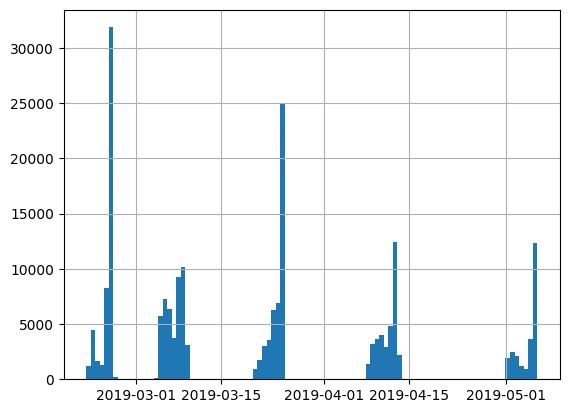

In [86]:
main_table[Cols.ServerTimestamp].hist(bins=100)

In [87]:
import numpy as np
for i in main_table[Cols.ServerTimestamp].quantile(np.arange(0, 1.01, 0.01)).to_list():
    print(i)

2019-02-20 17:40:39
2019-02-21 18:59:26
2019-02-21 21:10:12.700000
2019-02-22 14:36:33.260000
2019-02-23 15:05:22
2019-02-23 19:36:47.150000128
2019-02-23 22:41:53.700000
2019-02-24 00:57:49.280000
2019-02-24 05:22:09
2019-02-24 15:49:48
2019-02-24 18:16:18
2019-02-24 19:22:04
2019-02-24 20:18:43.400000
2019-02-24 21:21:10
2019-02-24 22:18:57
2019-02-24 23:04:56
2019-02-25 00:00:59
2019-02-25 00:39:22
2019-02-25 01:20:38
2019-02-25 01:48:50
2019-02-25 02:23:34.800000
2019-02-25 02:55:14.429999872
2019-02-25 03:30:04
2019-02-25 04:06:05
2019-02-25 04:40:19.560000
2019-03-04 17:53:29
2019-03-04 21:52:47
2019-03-05 05:09:43
2019-03-05 17:42:09
2019-03-05 20:54:09
2019-03-05 23:37:08
2019-03-06 03:46:03.240000
2019-03-06 14:18:15
2019-03-06 16:49:21
2019-03-06 20:57:41
2019-03-07 02:06:58
2019-03-07 15:23:56
2019-03-07 20:55:55
2019-03-08 00:27:42
2019-03-08 03:12:50.370000128
2019-03-08 05:30:25.400000
2019-03-08 15:55:22
2019-03-08 20:41:00.920000
2019-03-08 22:07:23
2019-03-09 00:24:33


In [88]:
#get the data of the third quantile
max = main_table[Cols.ServerTimestamp].max()
min = main_table[Cols.ServerTimestamp].min()
range = max - min
time_cutoff = min + range * 0.33
print(time_cutoff)
print(main_table[Cols.ServerTimestamp].min())
print(main_table[Cols.ServerTimestamp].max())

data_subset = main_table[main_table[Cols.ServerTimestamp] <= time_cutoff]
print("Assignment IDs:", data_subset[Cols.AssignmentID].unique())
print("Problem IDs:", data_subset[Cols.ProblemID].unique())
print("Total number of rows:", len(data_subset))
# Assignment IDs: [597 600]
# Problem IDs: [13 232 235 234 236   5 233   1   3  12  24 100 101  25 102  28  21  20  17  22]

2019-03-17 07:09:25.050000
2019-02-20 17:40:39
2019-05-06 03:58:44
Assignment IDs: [439. 487.]
Problem IDs: [234  13  12 232 233   5 235  25 236  21   1 102   3  24 100  28 101  22
  17  20]
Total number of rows: 94876


In [89]:
student_subset = data_subset[Cols.SubjectID].unique()[:50]
mt_subset = data_subset[data_subset[Cols.SubjectID].isin(student_subset)]

In [90]:
grouping_cols = [Cols.SubjectID, problem_id_col]

<Axes: ylabel='Frequency'>

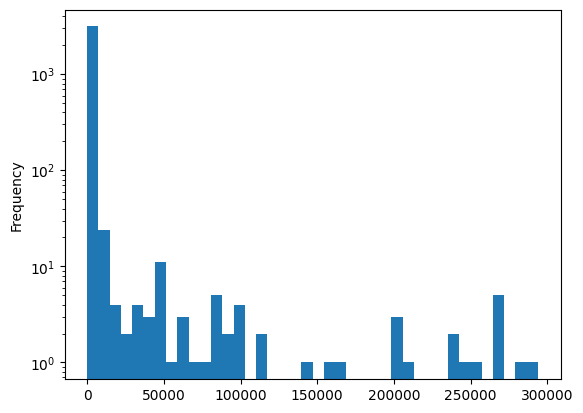

In [91]:
from analytics.metrics.time import TimeMetrics


diffs = TimeMetrics.get_all_diffs(mt_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [92]:
TimeMetrics.get_positive_diff_quantiles(data_subset, timestamp_col, grouping_cols) / 60

# Seems like 5 minutes (90th+ percentile) is a good cutoff for time spent on a problem between submissions
# 30m does seem to suggest that the student is not working on the problem

0.00       0.016667
0.25       0.283333
0.50       0.583333
0.75       1.416667
0.80       1.816667
0.85       2.483333
0.90       3.716667
0.95      10.483333
0.96      18.850000
0.97      40.325000
0.98     129.290000
0.99     792.715000
1.00    6236.666667
Name: DeltaSeconds, dtype: float64

In [93]:
time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
result

C:\Users\twprice\AppData\Local\Temp\ipykernel_2992\3690036271.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  PassiveTime  \
SubjectID                        ProblemID                            
00c54f9462673d4c09d2a88121860841 1                 0.0          0.0   
                                 3                 0.0          0.0   
                                 5                37.0          0.0   
                                 12                0.0          0.0   
                                 13              421.0          0.0   
...                                                ...          ...   
ffb72475a81de0e95b910ffad039f5c2 232            1630.0        571.0   
                                 233             120.0          0.0   
                                 234              40.0          0.0   
                                 235            1065.0          0.0   
                                 236               0.0          0.0   

                                            TotalTime  ActiveTimeAfterCorrect  \
SubjectID                        ProblemID                                      
00c54f9462673d4c09d2a88121860841 1                0.0                     0.0   
                                 3                0.0                     0.0   
                                 5               37.0                     0.0   
                                 12               0.0                    31.0   
                                 13             421.0                     0.0   
...                                               ...                     ...   
ffb72475a81de0e95b910ffad039f5c2 232           2201.0                     0.0   
                                 233            120.0                     0.0   
                                 234             40.0                     0.0   
                                 235           1065.0                     0.0   
                                 236              0.0                     0.0   

                                            #Breaks           StartTime  \
SubjectID                        ProblemID                                
00c54f9462673d4c09d2a88121860841 1                0 2019-02-24 05:13:03   
                                 3                0 2019-02-24 05:13:33   
                                 5                0 2019-02-24 05:09:54   
                                 12               0 2019-02-24 05:14:37   
                                 13               0 2019-02-24 04:27:49   
...                                             ...                 ...   
ffb72475a81de0e95b910ffad039f5c2 232              2 2019-02-24 07:04:21   
                                 233              0 2019-02-25 01:52:23   
                                 234              0 2019-02-25 01:25:54   
                                 235              0 2019-02-24 23:37:59   
                                 236              0 2019-02-25 01:32:22   

                                              FirstCorrectTime  \
SubjectID                        ProblemID                       
00c54f9462673d4c09d2a88121860841 1         2019-02-24 05:13:03   
                                 3         2019-02-24 05:13:33   
                                 5         2019-02-24 05:10:31   
                                 12        2019-02-24 05:14:37   
                                 13        2019-02-24 04:34:50   
...                                                        ...   
ffb72475a81de0e95b910ffad039f5c2 232       2019-02-25 01:18:45   
                                 233       2019-02-25 01:54:23   
                                 234       2019-02-25 01:26:34   
                                 235       2019-02-24 23:55:44   
                                 236       2019-02-25 01:32:22   

                                                       EndTime  
SubjectID                        ProblemID                      
00c54f9462673d4c09d2a88121860841 1         2019-02-24 05:13:03  
                                 3  

In [94]:
result.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
count,6859.000000,6859.000000,6859.000000,6859.000000,6859.000000,6859,6479,6859
mean,160.628809,97.085289,257.714098,4.661612,0.104534,2019-03-01 11:38:03.775477248,2019-03-01 09:39:10.098471936,2019-03-01 13:06:18.033095168
min,0.000000,0.000000,0.000000,0.000000,0.000000,2019-02-20 17:40:39,2019-02-20 21:17:01,2019-02-20 21:17:01
25%,0.000000,0.000000,0.000000,0.000000,0.000000,2019-02-24 20:35:45,2019-02-24 20:32:23.500000,2019-02-24 20:56:43.500000
50%,33.000000,0.000000,36.000000,0.000000,0.000000,2019-02-25 04:05:33,2019-02-25 03:55:47,2019-02-25 04:15:56
75%,181.500000,0.000000,227.000000,0.000000,0.000000,2019-03-07 05:29:36.500000,2019-03-07 04:49:30,2019-03-07 16:57:48.500000
max,5455.000000,5100.000000,8353.000000,2752.000000,7.000000,2019-03-09 04:58:46,2019-03-09 04:58:47,2019-03-09 04:58:59
std,325.835024,357.315763,581.078054,47.893497,0.398680,NaN,NaN,NaN


In [95]:
from analytics.metrics.score import SubmissionScoreMetrics
from spec.enums import EventType

score_metrics = SubmissionScoreMetrics(EventType.RunProgram)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_2992\2502026517.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [96]:
subject_problem_score.head()

Attempts  FirstCorrect  \
SubjectID                        ProblemID                           
00c54f9462673d4c09d2a88121860841 1                 1          True   
                                 3                 1          True   
                                 5                 2         False   
                                 12                1          True   
                                 13                5         False   

                                            EverCorrect  Attempted  MaxScore  \
SubjectID                        ProblemID                                     
00c54f9462673d4c09d2a88121860841 1                 True       True       1.0   
                                 3                 True       True       1.0   
                                 5                 True       True       1.0   
                                 12                True       True       1.0   
                                 13                True       True       1.0   

                                            MinScore  MeanScore  TotalAttempts  
SubjectID                        ProblemID                                      
00c54f9462673d4c09d2a88121860841 1              1.00      1.000              1  
                                 3              1.00      1.000              1  
                                 5              0.75      0.875              2  
                                 12             1.00      1.000              2  
                                 13             0.00      0.200              5

In [97]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,6859.000000,6859.000000,6859.000000,6859.000000,6859.000000
mean,4.324974,0.977825,0.449785,0.659819,4.445692
std,6.241619,0.120973,0.477079,0.322367,6.411914
min,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,0.000000,0.366667,1.000000
50%,2.000000,1.000000,0.000000,0.640000,2.000000
75%,5.000000,1.000000,1.000000,1.000000,5.000000
max,93.000000,1.000000,1.000000,1.000000,93.000000


In [98]:
all_features = pd.merge(
    result.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
all_features.head()

,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts
0,00c54f9462673d4c09d2a88121860841,1,0.0,0.0,0.0,0.0,0,2019-02-24 05:13:03,2019-02-24 05:13:03,2019-02-24 05:13:03,1,True,True,True,1.0,1.00,1.000,1
1,00c54f9462673d4c09d2a88121860841,3,0.0,0.0,0.0,0.0,0,2019-02-24 05:13:33,2019-02-24 05:13:33,2019-02-24 05:13:33,1,True,True,True,1.0,1.00,1.000,1
2,00c54f9462673d4c09d2a88121860841,5,37.0,0.0,37.0,0.0,0,2019-02-24 05:09:54,2019-02-24 05:10:31,2019-02-24 05:10:31,2,False,True,True,1.0,0.75,0.875,2
3,00c54f9462673d4c09d2a88121860841,12,0.0,0.0,0.0,31.0,0,2019-02-24 05:14:37,2019-02-24 05:14:37,2019-02-24 05:15:08,1,True,True,True,1.0,1.00,1.000,2
4,00c54f9462673d4c09d2a88121860841,13,421.0,0.0,421.0,0.0,0,2019-02-24 04:27:49,2019-02-24 04:34:50,2019-02-24 04:34:50,5,False,True,True,1.0,0.00,0.200,5


In [99]:
all_features.isna().mean()

SubjectID                 0.000000
ProblemID                 0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.055402
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.000000
MinScore                  0.000000
MeanScore                 0.000000
TotalAttempts             0.000000
dtype: float64

In [100]:
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [101]:
all_features.head()

,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts
0,00c54f9462673d4c09d2a88121860841,1,0.0,0.0,0.0,0.0,0,2019-02-24 05:13:03,2019-02-24 05:13:03,2019-02-24 05:13:03,1,True,True,True,1.0,1.00,1.000,1
1,00c54f9462673d4c09d2a88121860841,3,0.0,0.0,0.0,0.0,0,2019-02-24 05:13:33,2019-02-24 05:13:33,2019-02-24 05:13:33,1,True,True,True,1.0,1.00,1.000,1
2,00c54f9462673d4c09d2a88121860841,5,37.0,0.0,37.0,0.0,0,2019-02-24 05:09:54,2019-02-24 05:10:31,2019-02-24 05:10:31,2,False,True,True,1.0,0.75,0.875,2
3,00c54f9462673d4c09d2a88121860841,12,0.0,0.0,0.0,31.0,0,2019-02-24 05:14:37,2019-02-24 05:14:37,2019-02-24 05:15:08,1,True,True,True,1.0,1.00,1.000,2
4,00c54f9462673d4c09d2a88121860841,13,421.0,0.0,421.0,0.0,0,2019-02-24 04:27:49,2019-02-24 04:34:50,2019-02-24 04:34:50,5,False,True,True,1.0,0.00,0.200,5


In [102]:
subject_means = all_features_z.drop(problem_id_col, axis=1).groupby(Cols.SubjectID).mean()
subject_means.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts
SubjectID,,,,,,,,,,,,,,,,
00c54f9462673d4c09d2a88121860841,-0.439320,-0.181586,-0.369276,-0.011134,-0.249826,0.494663,0.225859,0.457451,-0.494267,0.750000,1.000000,1.0,0.177106,0.760289,0.756211,-0.494658
033ee034918011e4e34a7f97d464261f,-0.333431,-0.303236,-0.379835,-0.136213,-0.318750,-1.254953,-1.260696,-1.363972,-0.283869,0.250000,0.583333,1.0,-0.283394,0.109233,0.164246,-0.300815
036ad3e516c5bf3a4b3be35b137bcbb8,1.015806,0.128167,0.658912,0.796303,1.328017,-0.531050,0.225800,-0.330155,1.253774,0.100000,1.000000,1.0,0.177106,-0.764485,-0.939535,1.480943
04c32d4d95425f73b3a1d6502aed4d48,0.393640,0.020536,0.234908,-0.105187,-0.195517,-0.172627,0.225820,-0.215230,0.374854,0.250000,1.000000,1.0,0.177106,-0.111167,-0.096668,0.349112
0503bf609757acf2e75aa8cbc0d8323b,0.064867,-0.240011,-0.119561,-0.138216,-0.200805,0.547502,0.197106,0.526162,-0.043785,0.181818,1.000000,1.0,0.149361,-0.316196,0.078451,-0.064653


In [103]:
subject_totals = all_features_z.drop(problem_id_col, axis=1).groupby(Cols.SubjectID).sum()
subject_totals.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts
SubjectID,,,,,,,,,,,,,,,,
00c54f9462673d4c09d2a88121860841,-8.786407,-3.631721,-7.385518,-0.222677,-4.996519,9.893265,4.517181,9.149029,-9.885349,15,20,20,3.542115,15.205776,15.124229,-9.893158
033ee034918011e4e34a7f97d464261f,-4.001169,-3.638834,-4.558023,-1.634560,-3.825000,-15.059434,-15.128352,-16.367660,-3.406423,3,7,12,-3.400723,1.310794,1.970950,-3.609777
036ad3e516c5bf3a4b3be35b137bcbb8,20.316124,2.563341,13.178244,15.926069,26.560344,-10.621001,4.516000,-6.603107,25.075481,2,20,20,3.542115,-15.289702,-18.790708,29.618864
04c32d4d95425f73b3a1d6502aed4d48,7.872798,0.410725,4.698157,-2.103742,-3.910350,-3.452535,4.516392,-4.304606,7.497076,5,20,20,3.542115,-2.223348,-1.933367,6.982233
0503bf609757acf2e75aa8cbc0d8323b,0.713532,-2.640124,-1.315168,-1.520373,-2.208856,6.022523,2.168161,5.787787,-0.481640,2,11,11,1.642976,-3.478153,0.862959,-0.711186


In [104]:
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=Cols.SubjectID,
    how="outer"
)
subject_features.head()

,SubjectID,ActiveTime_x,PassiveTime_x,TotalTime_x,ActiveTimeAfterCorrect_x,#Breaks_x,StartTime_x,FirstCorrectTime_x,EndTime_x,Attempts_x,...,FirstCorrectTime_y,EndTime_y,Attempts_y,FirstCorrect_y,EverCorrect_y,Attempted_y,MaxScore_y,MinScore_y,MeanScore_y,TotalAttempts_y
0,00c54f9462673d4c09d2a88121860841,-0.439320,-0.181586,-0.369276,-0.011134,-0.249826,0.494663,0.225859,0.457451,-0.494267,...,4.517181,9.149029,-9.885349,15,20,20,3.542115,15.205776,15.124229,-9.893158
1,033ee034918011e4e34a7f97d464261f,-0.333431,-0.303236,-0.379835,-0.136213,-0.318750,-1.254953,-1.260696,-1.363972,-0.283869,...,-15.128352,-16.367660,-3.406423,3,7,12,-3.400723,1.310794,1.970950,-3.609777
2,036ad3e516c5bf3a4b3be35b137bcbb8,1.015806,0.128167,0.658912,0.796303,1.328017,-0.531050,0.225800,-0.330155,1.253774,...,4.516000,-6.603107,25.075481,2,20,20,3.542115,-15.289702,-18.790708,29.618864
3,04c32d4d95425f73b3a1d6502aed4d48,0.393640,0.020536,0.234908,-0.105187,-0.195517,-0.172627,0.225820,-0.215230,0.374854,...,4.516392,-4.304606,7.497076,5,20,20,3.542115,-2.223348,-1.933367,6.982233
4,0503bf609757acf2e75aa8cbc0d8323b,0.064867,-0.240011,-0.119561,-0.138216,-0.200805,0.547502,0.197106,0.526162,-0.043785,...,2.168161,5.787787,-0.481640,2,11,11,1.642976,-3.478153,0.862959,-0.711186


In [105]:
assert subject_features.isna().mean().mean() == 0

In [106]:
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,SubjectID,ActiveTime_x,PassiveTime_x,TotalTime_x,ActiveTimeAfterCorrect_x,#Breaks_x,StartTime_x,FirstCorrectTime_x,EndTime_x,Attempts_x,...,FirstCorrectTime_y,EndTime_y,Attempts_y,FirstCorrect_y,EverCorrect_y,Attempted_y,MaxScore_y,MinScore_y,MeanScore_y,TotalAttempts_y
0,00c54f9462673d4c09d2a88121860841,-0.870061,-0.479168,-0.800249,-0.015062,-0.546516,0.551992,0.428790,0.505918,-0.931539,...,0.564414,0.633425,-1.150303,1.891371,0.751476,0.629716,0.457681,1.833732,1.804722,-1.130746
1,033ee034918011e4e34a7f97d464261f,-0.669924,-0.777989,-0.821943,-0.309527,-0.692948,-1.605898,-1.413141,-1.746801,-0.550983,...,-1.890263,-1.133200,-0.396386,-0.742923,-1.665520,-0.992264,-0.439411,0.158074,0.235187,-0.412582
2,036ad3e516c5bf3a4b3be35b137bcbb8,1.880211,0.281708,1.312180,1.885827,2.805662,-0.713072,0.428717,-0.468187,2.230205,...,0.564267,-0.457160,2.917894,-0.962447,0.751476,0.629716,0.457681,-1.843853,-2.242230,3.385310
3,04c32d4d95425f73b3a1d6502aed4d48,0.704281,0.017324,0.441056,-0.236485,-0.431136,-0.271010,0.428741,-0.326049,0.640471,...,0.564316,-0.298025,0.872393,-0.303874,0.751476,0.629716,0.457681,-0.268123,-0.230702,0.798039
4,0503bf609757acf2e75aa8cbc0d8323b,0.082881,-0.622683,-0.287205,-0.314242,-0.442370,0.617161,0.393163,0.590899,-0.116737,...,0.270908,0.400712,-0.056046,-0.962447,-0.921829,-1.195012,0.212291,-0.419446,0.102974,-0.081285


In [114]:
grades = dataset.get_link_table("Subject")
grades.head()

,SubjectID,X-Grade
0,65be44ae7088566069cc3bef454174a7,0.3600
1,0bdf2c1f053650715e1f0c725d754b96,0.3917
2,ff12b08dbcd163de643a3f597b14c6e4,0.0000
3,ad8d3a0a0f0a084a97fad357c649438c,0.6160
4,f4db8537e9d75da46c4efc36a2d70956,0.4310


In [115]:
grade_col = "X-Grade"
grades.rename(columns={grade_col: "Grade"}, inplace=True)

# CWO only: drop 0 grades
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 32 rows with 0 grades


In [116]:
subject_feautres_labeled = pd.merge(
    subject_feautres_z.reset_index(),
    grades,
    on=Cols.SubjectID,
    how="inner"
)

In [120]:
print(len(subject_feautres_labeled))
dir = os.path.join(dataset.data_config.root_path, "analysis")
if not os.path.exists(dir):
    os.makedirs(dir)
subject_feautres_labeled.to_csv(os.path.join(dir, "subject_features.csv"), index=False)

342
